This notebook assumes that it is run from docs/tutorials (as a current directory of jupyter lab).

In [71]:
import arviz as az
import numpy as np
import random
import pandas as pd
import scipy.stats as stats
import xarray as xr
from matplotlib import pyplot as plt
from IPython.display import Markdown


# move to a directory to above access the privugger code
import os, sys
sys.path.append(os.path.join("../../"))

In [2]:
# privugger library
import privugger as pv

from IPython.display import display, clear_output

$S$ - the number of students    
$C$ - the number of courses  
$k_i$ - the number of courses the $i$th student is registered in  
$l_j$ - the number of seats in $j$th course  (needs to be somewhat consistent with the above, there should be enough seats for the students)  
$e_{i,j}$ - The $i$th student is enrolled in $j$th course, $i=1..S$, $j=1..C$  
$c_{i,j}$ - the number of comments written by the $i$th student for the $j$th course

A student can only write a comment on the courses they are enrolled in.  
The comments of the student for one course are consecutive, and there is a small chance of interleaving comment block for courses from different students.  
The students work on the course evaluation in an unknown order. Discovering that order, would almost fully re-identify the authors of the comments.

# Synthetic Data Generation

Let's generate a synthetic dataset. 

In [3]:
S = 300  # number of students in the programme
C = 40   # number of courses offered this term

We first generate the number $k$ of courses each student takes,
assuming each student registers in at most 5 courses at a time, 
with mean 3.3, so $p = \mu/n$. The two constants are based on our 
prior knowledge about the software study programs at the IT University of Copenhagen.

In [4]:
k = np.random.binomial(n = 5, p = 3.3 / 5.0, size = S)
k

array([3, 4, 4, 4, 3, 2, 4, 2, 4, 3, 4, 3, 1, 2, 3, 4, 2, 4, 4, 4, 5, 4,
       2, 1, 3, 4, 2, 3, 2, 4, 4, 4, 3, 3, 4, 3, 4, 3, 3, 4, 4, 4, 4, 5,
       3, 4, 3, 5, 5, 3, 3, 3, 4, 4, 2, 3, 5, 4, 1, 3, 5, 2, 3, 4, 4, 3,
       4, 5, 3, 3, 4, 3, 4, 3, 3, 1, 4, 2, 4, 4, 2, 5, 3, 2, 3, 2, 4, 3,
       4, 2, 3, 3, 5, 2, 4, 1, 4, 5, 1, 2, 2, 4, 1, 2, 3, 3, 2, 1, 4, 3,
       3, 3, 5, 5, 2, 5, 2, 5, 2, 5, 3, 4, 2, 2, 2, 1, 1, 3, 5, 3, 2, 5,
       4, 3, 1, 2, 4, 3, 3, 3, 4, 1, 3, 2, 5, 5, 2, 4, 4, 4, 4, 4, 5, 3,
       1, 4, 3, 3, 3, 2, 2, 4, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 5, 3,
       2, 5, 4, 2, 2, 4, 2, 4, 4, 3, 4, 1, 4, 4, 3, 2, 1, 5, 3, 3, 2, 5,
       3, 4, 2, 3, 3, 3, 5, 5, 5, 4, 3, 3, 2, 5, 5, 4, 3, 2, 4, 3, 4, 5,
       4, 2, 3, 3, 2, 3, 3, 3, 4, 3, 5, 3, 3, 3, 2, 4, 5, 3, 3, 2, 5, 5,
       3, 3, 4, 5, 3, 4, 5, 4, 2, 3, 4, 4, 1, 3, 4, 5, 5, 1, 3, 4, 3, 2,
       2, 3, 2, 2, 4, 4, 4, 5, 5, 1, 4, 5, 3, 3, 3, 3, 2, 3, 4, 2, 5, 3,
       4, 3, 2, 4, 4, 4, 3, 5, 4, 5, 3, 4, 4, 1])

Now  generate the number of seats on each course, as we want to 
have both large and small courses.  A typical course takes 20 students (the number of seats is larger, but not all are taken).
It turns out that a Poisson distribution has too low variance for modeling the course size distribution at IT University.  
The smallest courses I get from Poisson are about 14 students, and the largest are ca. 34.  The spread at ITU is much larger.  Thus I tried with negative binomial, and shift the sample right by 15, to ensure that each course has at least 15 seats. I think about 15 is a minimum seat assignment at ITU typically.  Unlike Poisson, negative binomial allows choosing a different mean and standard deviation.


In [5]:
μ_size = 30
σ_size = 50
r_size = μ_size * μ_size / (σ_size * σ_size - μ_size)
p_size = μ_size /(σ_size * σ_size)
# sample C courses, then fix everything by 4, so that the smallest courses have 4 students`
l = np.random.negative_binomial(n = r_size, p = p_size, size = C)
l = l + 15
l

array([ 58,  18,  76,  16, 114,  44,  74,  33,  23,  18,  41, 220,  22,
        71,  88, 185,  15,  19,  15,  16,  95,  51,  27,  39,  15,  21,
        99,  15,  56,  15, 112,  40, 121,  16,  29,  77,  35,  23,  27,
        15])

Let's plot the distribution of course sizes (defined as number of seats offered).

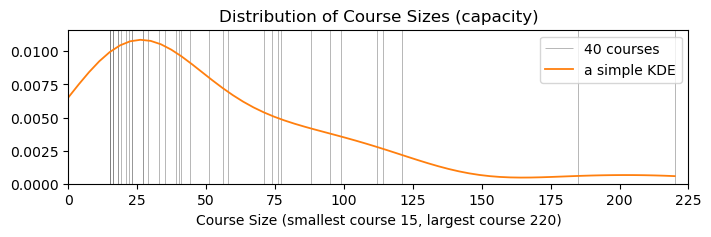

In [6]:
l_sorted = np.sort(l)
_ ,ax = plt.subplots (1, figsize = (8, 2))
ax.vlines(x = l_sorted, ymin = 0, ymax = 2, colors = 'gray', lw = .4, label = f"{len(l)} courses")

xs = np.linspace(0, l_sorted[-1], 60)
kde = stats.gaussian_kde(l_sorted).evaluate(xs)
ax.plot(xs, kde, color = 'C1', lw = 1.3, label = f"a simple KDE")

ax.set_title("Distribution of Course Sizes (capacity)")
ax.set_xlim(0, l.max()+5)
ax.set_ylim(0, kde.max()*1.07)
ax.set_xlabel(f"Course Size (smallest course {l.min()}, largest course {l.max()})")
ax.legend();

Check that there are enough seats for all students in the courses


In [7]:
k_sum = k.sum() # the total number of registrations to execute
l_sum = l.sum() # the total number of course seats available
assert l_sum >= k_sum, f"There is only {l_sum} seats int the courses but students ask for {k_sum}"

Populate courses with students. We assign the students with more unassigned courses first, and the larger courses first. More precisely, we give these a probabilistic upper hand.

In [8]:
e = np.zeros((S, C), dtype=int)
while k_sum > 0:
    p_enrollments = k / k_sum # prob. distribution of picking up a student
    p_seats = l / l_sum       # prob. distribution of picking up a course
    i = np.random.choice(S, p = p_enrollments)
    k[i] -= 1
    k_sum -= 1
    j = np.random.choice(C, p = p_seats)
    l[j] -= 1
    l_sum -= 1
    e[i,j] = 1
e

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

(NB. `e[i][j] = 1` is the $i$th student being enrolled in the $j$th course).

Plot of the actual registrations (the actual course sizes after the registration process).

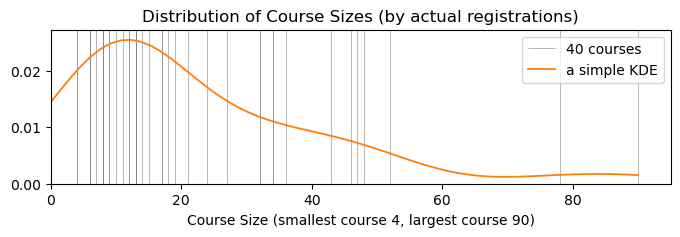

In [9]:
r_sorted = np.sort(np.array([np.sum(e[:,course]) for course in range(C)]))
r_sorted = r_sorted[r_sorted >= 3] # cancel courses below three students
_ ,ax = plt.subplots (1, figsize = (8, 2))
ax.vlines(x = r_sorted, ymin = 0, ymax = 2, colors = 'gray', lw = .4, label = f"{len(r_sorted)} courses")

r_xs = np.linspace(0, r_sorted[-1], 60)
r_kde = stats.gaussian_kde(r_sorted).evaluate(r_xs)
ax.plot(r_xs, r_kde, color = 'C1', lw = 1.3, label = f"a simple KDE")

ax.set_title("Distribution of Course Sizes (by actual registrations)")
ax.set_xlim(0, r_sorted.max()+5)
ax.set_ylim(0, r_kde.max()*1.07)
ax.set_xlabel(f"Course Size (smallest course {r_sorted.min()}, largest course {r_sorted.max()})")
ax.legend();

And as a sanity check plot also the number of registrations per students (so how many courses students take).

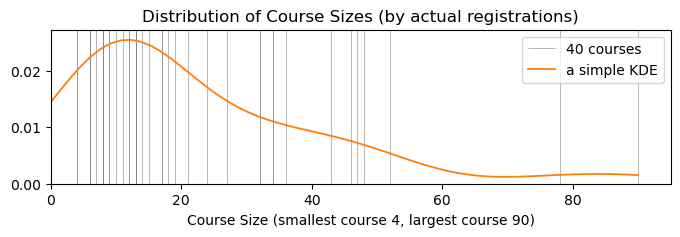

In [9]:
# REMOVE r_sorted = np.sort(np.array([np.sum(e[:,course]) for course in range(C)]))
# REMOVE r_sorted = r_sorted[r_sorted >= 3] # cancel courses below three students
# FIXME: cancelling courses should update the e table!
s_sorted = np.sort([np.sum(e[student,:]) if  for student in range(S)]
_ ,ax = plt.subplots (1, figsize = (8, 2))
# FIX ax.vlines(x = r_sorted, ymin = 0, ymax = 2, colors = 'gray', lw = .4, label = f"{len(r_sorted)} courses")

r_xs = np.linspace(0, r_sorted[-1], 60)
r_kde = stats.gaussian_kde(r_sorted).evaluate(r_xs)
ax.plot(r_xs, r_kde, color = 'C1', lw = 1.3, label = f"a simple KDE")

ax.set_title("Distribution of Course Sizes (by actual registrations)")
ax.set_xlim(0, r_sorted.max()+5)
ax.set_ylim(0, r_kde.max()*1.07)
ax.set_xlabel(f"Course Size (smallest course {r_sorted.min()}, largest course {r_sorted.max()})")
ax.legend();

In [10]:
# sanity check
# the largest course (r_sorted[-1]) has less students than the number of seats assigned to the largest course (l_sorted[-1])
assert l_sorted[-1] >= r_sorted[-1]

Reduce the number of courses to those that are actually running (some might have received no registrations)

In [11]:
C = len(r_sorted)
C

40

We first generate the student comments for the courses they are enrolled in.
Assume that a typical student writes two comments per course.  We are not yet ordering these comments in any way.

In [12]:
c = np.random.poisson(lam = 2, size=(S, C))
total_comments = c.sum()
total_comments

24027

We shall now schedule writing the above comments in time.  Assume that there are $H$ hours for performing the evaluation. For simplicity, a student performs evaluation within an hour. Then $H = 250$ amounts to about 10 days (by decreasing this number we introduce more noise, as more students will write evaluations at the same time, and their indices will be conflated.

In [13]:
H = 250 

Randomly assign the writing hour for each student (`h[t]` is the time when student evaluates).

In [14]:
h = np.random.choice(range(H), size=S)
h

array([ 75,  62, 163, 124,  61, 233,  44, 177,  98,  70, 236, 188, 112,
        33, 241, 131,  70,  64,  70,  81, 249,  14, 118, 208, 205, 168,
       218, 146, 210, 141,  99, 211, 156,  25,  19,   6, 144,  63, 120,
       168,  67,  22, 142,  30,  53,  16, 177,  32,  80,  18,   1, 225,
       191, 133, 189,  52,  79, 159, 144, 222, 139, 110, 147, 148, 137,
       155, 131,  39, 134, 219, 186, 163, 173, 153, 152, 182, 222,   9,
        25, 122, 180, 216,   1,  12, 227, 176, 232,  67, 180, 161, 102,
        15,  70,  22,  81,  33, 177,  86,  95, 154, 115, 108, 243, 148,
       227, 132, 177, 154, 182, 198,   9,   4, 194, 164,  92, 203,  55,
        73,  52,  24, 205, 247, 131,  48, 179, 167,  52, 241, 167,  83,
       123,  73, 140, 199, 194, 134, 221, 225, 220,  47, 193, 137,  71,
       182, 103,  81, 195,  99, 144, 153,  29, 155, 159,  88, 215,  87,
       135, 150, 239, 180, 170,   0, 118,  95, 243,  25,  62,  11, 239,
       190, 191, 136, 245,  91, 245,  94,  27, 207, 176,  96, 15

We are going to store the evaluation log visible in the online system in the `output` variable as quadruples: time, student, course, and a comment id. The loop below produces the output, for all the time interval, shuffling the students randomly.  Note that comments for a single course are not mixed between students (they receive consecutive ids).  Comments for different courses may interleave between students (actually a more leaking implementation would not mix courses, and we can also try that).

In [15]:
output = []
available_comment_id = 0

for t in range(H):
    # students allocated to the current hour (the first component is the actual array)
    active_students = np.where(h == t)[0]
    # narrow down to students that have not written all their comments yet
    active_students = [ student_id for student_id in active_students if c[student_id,:].sum() > 0 ]
    
    while active_students:
        student_id = random.choice(active_students)
        # write comments in the order of courses (we take them in the order of increasing course ids)
        course_id = np.argmax(c[student_id, :] > 0)
        evaluations = [ (t, student_id, course_id, available_comment_id + comment_id) 
                        for comment_id 
                        in range(c[student_id, course_id]) ]
        output.extend(evaluations)
        available_comment_id += c[student_id, course_id]
        c[student_id, course_id] = 0
        if c[student_id, :].sum() == 0:
            active_students.remove(student_id)
        

An evaluation is a tuple: time, student, course, comment_id

In [16]:
output = pd.DataFrame(output, columns = ['t', 'student', 'course', 'comment'])
output['position'] = range(len(output))
output.set_index(["position"], inplace = True)
output = xr.Dataset.from_dataframe(output)

In [17]:
output

<xarray.Dataset>
Dimensions:   (position: 24027)
Coordinates:
  * position  (position) int64 0 1 2 3 4 5 ... 24022 24023 24024 24025 24026
Data variables:
    t         (position) int64 0 0 0 0 0 0 0 0 ... 249 249 249 249 249 249 249
    student   (position) int64 161 161 161 161 161 161 161 ... 20 20 20 20 20 20
    course    (position) int64 1 1 1 2 3 3 3 4 4 ... 35 35 35 36 37 37 37 38 38
    comment   (position) int64 0 1 2 3 4 5 ... 24022 24023 24024 24025 24026

# Leakage Modeling

* We have now generated the data. What we want to do is to release the comment column.
* The attacker has access to student enrolement (the $e_{ij}$ array). 
* We want to measure leakage of information to the non-existant (explicitly) variable comment-author $a_{ij}$ that matches the student $i$ to a comment $j$. We want to find maximum leakage of this kind (find some individuals), ideally given an existing data set (so different from the ESORICS scenario).
  * One way to do this: model everything with priors, compose with $e_ij$, this reduces uncertainty. So to simplify things $e_ij$ goes into the prior.
  * How can the result of the analysis be used with the existing data set? We can also check the prediction error? A new kind of leakage maesure?
  * We could difference from mode solution, or compare the mode posterior probability and the actual dataset probability; possibly also zoomed at the individual students, to see who is most vulnerable. 
* The PyMC model should have the data generated by the above process ($e_{i,j}$) and the time series of comments and course ids $\{i,j\}$.
* Let's start with prototyping the disclosure program to make things more concrete:

In [18]:
def release(dataset):
    student_course     = np.array(list(set(zip(dataset.student.values, dataset.course.values)))) 
    # why this is not from e_ijs? (not sure if this matters; but it seems to hint which students 
    # are considered as it does not include the students that have not written comments)
    # TODO: and it seems that not having a single source of truth is a problem; we should fix e_ij and use it...
    sorted_student_ids = np.argsort(student_course[:, 0])
    student_course     = student_course[sorted_student_ids]

    comment_course     = np.array(list(zip(dataset.comment.values, dataset.course.values)))

    return student_course, comment_course
    

In [19]:
student_course, comment_course = release(output)
student_course

array([[  0,  30],
       [  0,  18],
       [  0,   4],
       ...,
       [299,  14],
       [299,  32],
       [299,  34]])

student -> course

Q: Why there is so much sorting in the second column below? Shouldn't the sorting be disrupted at most every courses?

The attacker wants to learn is: comment -> student (or student -> comment)

## Understanding the dimensionality of the problem

What's the minimal number of student-comment variables we need? The attacker knows in which courses the student is registered.

**TODO:** students are registered for too many courses! We need a plot with a student - course count distribution above. Fix the bug, then the code below should be able to get dimensionality.

In [73]:
# Group by course_id using a dictionary
comments_per_course = {}
for _, course_id in comment_course:
    comments_per_course[course_id] = grouped.get(course_id, 0) + 1

# Convert to a simpler array
stud_comment_count = sum([ comments_per_course[course] for student, course in student_course])
display (Markdown(f"We need **{stud_comment_count}** variables to model the association between the students and comments, if we exploit the registration data in the model structure."))

We need **6231782** variables to model the association between the students and comments, if we exploit the registration data in the model structure.

**TODO**: A sanity check is to calculate the same thing from looking at how many students each course has. It should give the same number?

# Privugger

* Start with a naive attacker, some uniform weak priors\n",
* Make a Boolean array students $\\times$ comments (the $e$ array serves as a likelihood perhaps). This could allow to build a model without the timining information. But then how can we reason about leakage in this model? As a baseline for another model?\n",       ....
* Causal secondary information: consecutive ids.
* We could also have a prior with 0.5 in the comments array (we could infer the probability that the student has written a comment, and compare it with the ground truth).
* Consider how we can anonymize it somehow (DP or so)
* 250114
    * Can we analyze for one student at a time? We did this in the netflix example.

In [21]:
student_no = max(student_course [:,0])+1
course_no = max(student_course[:,1])
comment_no = max(comment_course[:,0])

We want to model a relation: Distrib(P(student_id x comment_id)), but it should be easier Dist(student_id x comment_id), or even student_id x Dist(Boolean)^comment_id

Assume that the number of students, course, and comment_no (get them from the observation and make constants in prior)

In [22]:
c2s = pv.Uniform("c2s", lower=0.0, upper=1.0, num_elements= (comment_no, student_no))

The above seems extensional. As now we really have a 3D space ... I think there was a way to make it simpler, where observations where coming from the comments arrays only